In [1]:
import os
import mne
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import gc
from autoreject import AutoReject
root_dir = r"E:\ecf-exp2-notif-mmn\data\Processed\\"



In [2]:
# from mne.utils import set_config

# from mne.utils import get_config
# set_config('MNE_USE_CUDA', 'true')
mne.set_log_level('WARNING')  # Options: 'DEBUG', 'INFO', 'WARNING', 'ERROR', 'CRITICAL'
# # Check that the config is set
# print(get_config('MNE_USE_CUDA')) 
#mne.set_memmap_min_size('100M')

# SN analysis

In [ ]:
def collect_epoch_for_evoke(folder_path,evn_id ='S15' ):
    concatenated_epochs = None
    total_trial = dict()
    all_epochs_list = []
    for subject in os.listdir(folder_path):
        subject_path = os.path.join(folder_path, subject)
        print(subject_path,subject[-6:-4])
        if subject_path.endswith('.fif') :
                print(f"Reading: {subject_path}")
                epochs = mne.read_epochs(subject_path, preload=True)
                # evns = list(epochs.event_id.values())
                # evn_names = ["S14","S15","S24","S25"]
                # correct_event_id = {evn_id:evn_name for evn_id, evn_name in zip(evns,evn_names)}
                # epochs.event_id = {v: k for k, v in correct_event_id.items()}
                epochs = epochs[evn_id]
                evn_id_dict= epochs.event_id
                old_env_idx = evn_id_dict[evn_id]
                new_evn_idx= 10000 + int(evn_id[1:])
                epochs.events[epochs.events[:, 2] == old_env_idx, 2] = new_evn_idx
                epochs.event_id = {evn_id :new_evn_idx }
                print(epochs.event_id)
                # epochs.resample(256)
                all_epochs_list.append(epochs[evn_id].pick(['Cz','Fz',"Fz"]))
                    
                
                # Optional: explicitly delete to free memory
                print(f"subject {subject[:-4]} : No of {evn_id} : {len(epochs[evn_id])}" ,)
                
                total_trial[subject[:-4]] = len(epochs)
                del epochs
                gc.collect()  
            # except Exception as e:
            #     print(f"Could not read {subject_path}: {e}")
            
    concatenated_epochs = mne.concatenate_epochs( all_epochs_list)
    del  all_epochs_list
    gc.collect()
    evoked = concatenated_epochs.average()
    print(f"subject {subject[:-4]} : No of total {evn_id} : {len(concatenated_epochs[evn_id])}")
    # Compute standard deviation across epochs
    total_trial["total_trial"] = len(concatenated_epochs)
    data = concatenated_epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
    del concatenated_epochs
    gc.collect()
    mean = cp.mean(data, axis=0)           # shape: (n_channels, n_times)
    std = cp.std(data, axis=0, ddof=1)             # shape: (n_channels, n_times)
    
    return {"event_id":evn_id,
            "evoke" :evoked,
            "mean" : mean,
            "SD" : std,
            "trial_details": total_trial}




E:\ecf-exp2-notif-mmn\data\Processed\\audio a
E:\ecf-exp2-notif-mmn\data\Processed\\BN_deviant_evoked_all_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\BN_deviant_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\BN_standard_evoked_all_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\BN_standard_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\CN_deviant_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\CN_standard_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Exp 0.xlsx 0.
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Participant Data.xlsx a.
E:\ecf-exp2-notif-mmn\data\Processed\\ECF_smartphone_survey.xlsx y.
E:\ecf-exp2-notif-mmn\data\Processed\\Participant_details.xlsx s.
E:\ecf-exp2-notif-mmn\data\Processed\\README.md DM
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_all_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_all_dict.pkl ct
E:\ecf-exp2-no

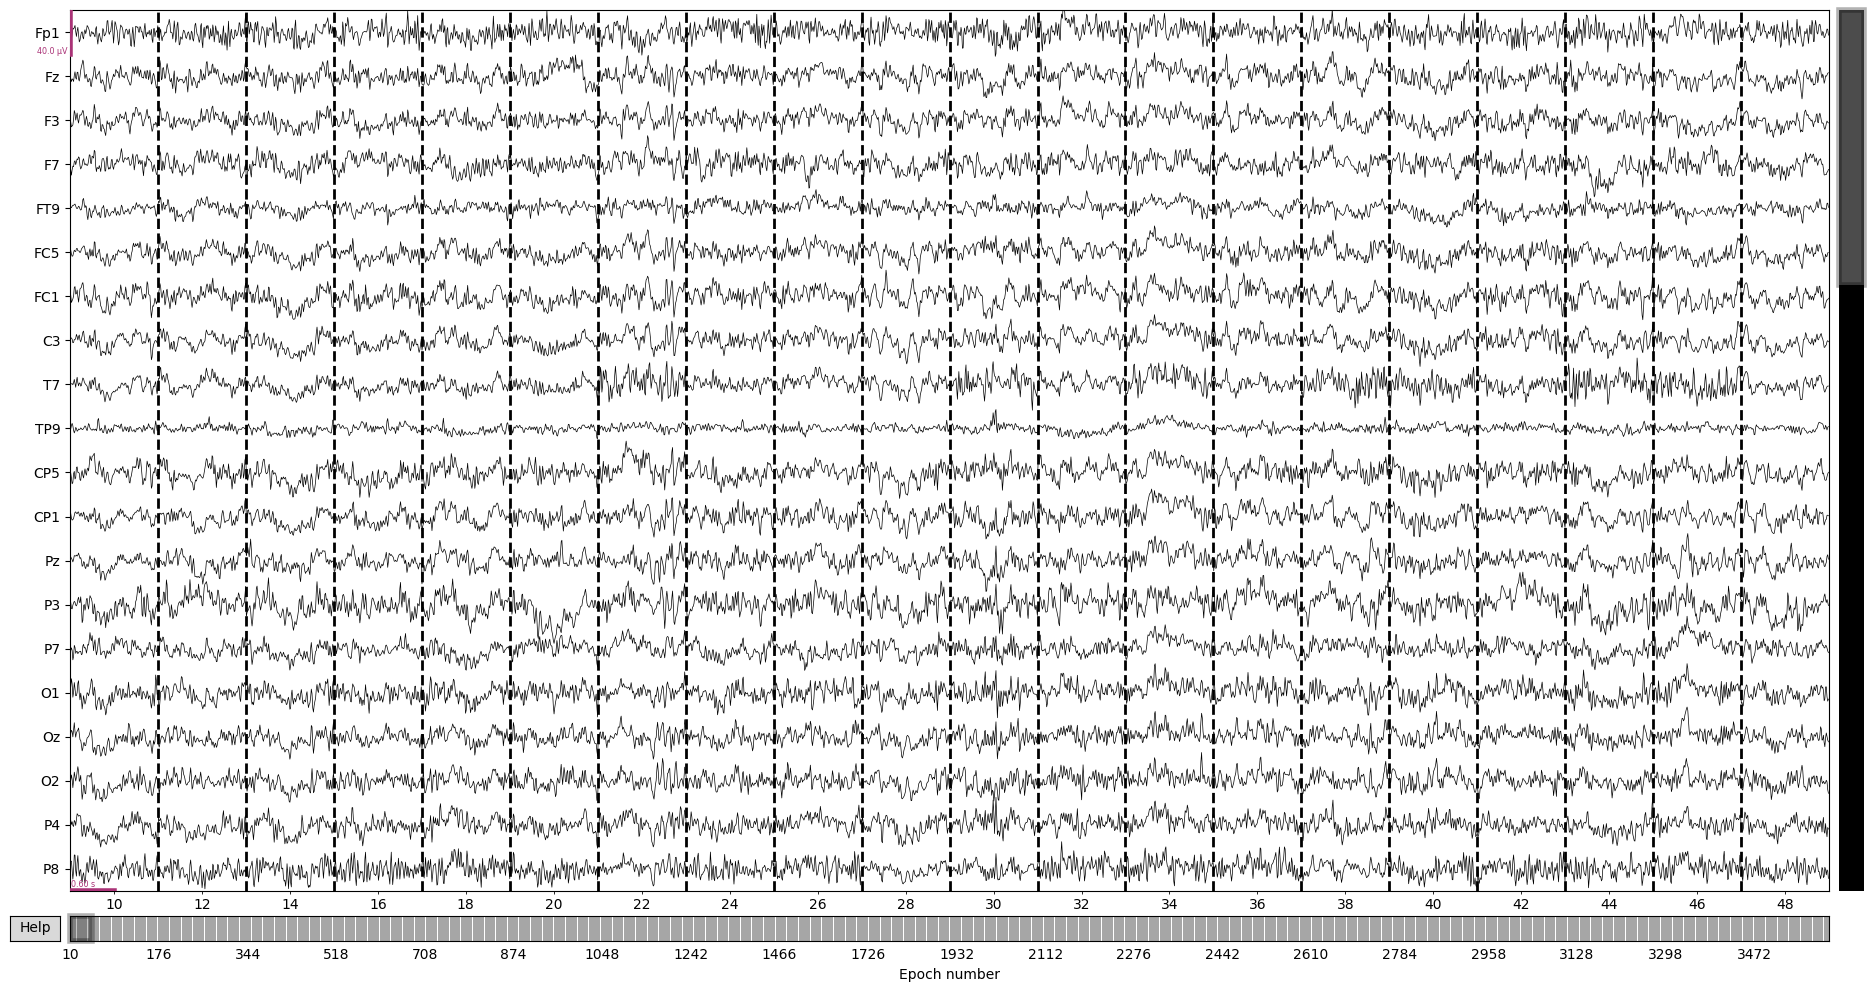

E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011.set 11
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd012-epo.fif po
Reading: E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd012-epo.fif


In [ ]:
SN_deviant = collect_epoch_for_evoke(root_dir,evn_id ='S15' )

In [4]:
evn_id ='S15'
int(evn_id[1:])

15

In [13]:
SN_deviant = collect_epoch_for_evoke(root_dir,evn_id ='S15' )
#SN_sta = collect_epoch_for_evoke(root_dir,evn_id ='S24' )

E:\ecf-exp2-notif-mmn\data\Processed\\audio
E:\ecf-exp2-notif-mmn\data\Processed\\BN_deviant_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\BN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\BN_standard_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\BN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\CN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\CN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Exp 0.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Participant Data.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\ECF_smartphone_survey.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\Participant_details.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\README.md
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_d

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    6.6s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    6.6s


[Done]
subject sub-sd059-epo : No of S15 : 149
subject sub-sd059-epo : No of S15 : 149
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd059.set
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd060-epo.fif
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd060.set
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd061-epo.fif
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd061.set
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd062-epo.fif
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd062.set
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd063-epo.fif
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd063.set
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd064-epo.fif
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd064.set
E:\ecf-exp2-notif-mmn\data\Processed\\sub002


In [6]:
SN_sta = collect_epoch_for_evoke(root_dir,evn_id ='S24' )    

E:\ecf-exp2-notif-mmn\data\Processed\\audio a
E:\ecf-exp2-notif-mmn\data\Processed\\BN_deviant_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\BN_standard_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\CN_deviant_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\CN_standard_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Exp 0.xlsx 0.
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Participant Data.xlsx a.
E:\ecf-exp2-notif-mmn\data\Processed\\ECF_smartphone_survey.xlsx y.
E:\ecf-exp2-notif-mmn\data\Processed\\Participant_details.xlsx s.
E:\ecf-exp2-notif-mmn\data\Processed\\README.md DM
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_dict.pkl ct
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011-epo.fif po
Reading: E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011-epo.fif
{'S24': 10024}
subject sub-sd011-epo : No of S24 : 750
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011.set 11
E

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_121872\118520751.py:35: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  concatenated_epochs = mne.concatenate_epochs( all_epochs_list)


subject su : No of total S24 : 35788


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_121872\118520751.py:42: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = concatenated_epochs.get_data()  # shape: (n_epochs, n_channels, n_times)


In [9]:
import numpy as np
# z-score for two-tailed CI
from scipy.stats import norm
def compute_difference_erp_with_ci(erp1, erp2, alpha=0.05):
    """
    Compute the difference ERP (erp1 - erp2) and its confidence interval.
    erp1, erp2: dictionaries as returned by your function.
    Returns: diff_mean, lower_ci, upper_ci (all arrays of shape [n_channels, n_times])
    """
    mean1 = erp1["mean"]
    mean2 = erp2["mean"]
    sd1 = erp1["SD"]
    sd2 = erp2["SD"]
    n1 = erp1["trial_details"]["total_trial"]
    n2 = erp2["trial_details"]["total_trial"]

    # Difference mean
    diff_mean = mean1 - mean2

    # Standard error of the difference
    se_diff = np.sqrt((sd1**2) / n1 + (sd2**2) / n2)

    
    z = norm.ppf(1 - alpha/2)

    # Confidence intervals
    lower_ci = diff_mean - z * se_diff
    upper_ci = diff_mean + z * se_diff

    return diff_mean, lower_ci, upper_ci


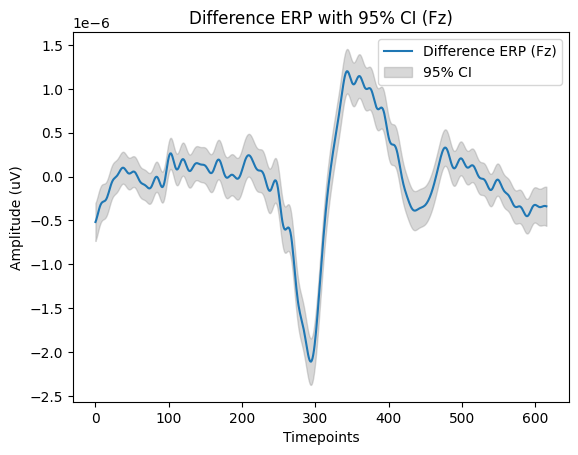

In [23]:


diff_mean, lower_ci, upper_ci = compute_difference_erp_with_ci(SN_deviant, SN_sta)

# For example, plot the difference ERP for Fz channel at all timepoints
import matplotlib.pyplot as plt

channel_names = SN_deviant["evoke"].ch_names
fz_idx = channel_names.index('Fz')

plt.plot(diff_mean[fz_idx], label='Difference ERP (Fz)')
plt.fill_between(
    np.arange(diff_mean.shape[1]),
    lower_ci[fz_idx],
    upper_ci[fz_idx],
    color='gray', alpha=0.3, label='95% CI'
)
plt.xlabel('Timepoints')
plt.ylabel('Amplitude (uV)')
plt.legend()
plt.title('Difference ERP with 95% CI (Fz)')
plt.show()
del plt


In [14]:
folder =  r"E:\ecf-exp2-notif-mmn\data\Processed\\"
SN_deviant_file = "SN_deviant_evoked_all_dict.pkl"
SN_std_file = "SN_standard_evoked_all_dict.pkl"

In [ ]:


CN_deviant_file = "CN_deviant_evoked_dict.pkl"
CN_std_file = "CN_standard_evoked_dict.pkl"
import pickle

BN_deviant_file = "BN_deviant_evoked_dict.pkl"
BN_std_file = "BN_standard_evoked_dict.pkl"
# Save each to its own file
with open(os.path.join(folder,SN_deviant_file), 'wb') as f:
    pickle.dump(SN_deviant, f)

with open(os.path.join(folder,SN_std_file), 'wb') as f:
    pickle.dump(SN_sta, f)

del SN_sta,SN_deviant

In [24]:
from pympler import asizeof
import pandas as pd

def list_variable_sizes(local_vars, top_n=20):
    var_data = []
    for var_name, val in local_vars.items():
        if var_name.startswith("__"):
            continue  # skip internal vars
        try:
            size_mb = asizeof.asizeof(val) / 1e6
            var_data.append((var_name, type(val).__name__, size_mb))
        except Exception as e:
            var_data.append((var_name, type(val).__name__, None))

    df = pd.DataFrame(var_data, columns=["Variable", "Type", "Size_MB"])
    df = df.sort_values(by="Size_MB", ascending=False).reset_index(drop=True)
    return df.head(top_n)

# Usage
list_variable_sizes(globals())
#how top 20 largest


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\pympler\asizeof.py:651: UserWarning: Iterating '<class 'traitlets.config.loader.Config'>': TypeError("'LazyConfigValue' object is not iterable")
  warnings.warn("Iterating '%s': %r" % (_classof(obj), x))
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\pympler\asizeof.py:651: UserWarning: Iterating '<class 'traitlets.config.loader.Config'>': TypeError("'LazyConfigValue' object is not iterable")
  warnings.warn("Iterating '%s': %r" % (_classof(obj), x))
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\pympler\asizeof.py:651: UserWarning: Iterating '<class 'traitlets.config.loader.Config'>': TypeError("'LazyConfigValue' object is not iterable")
  warnings.warn("Iterating '%s': %r" % (_classof(obj), x))
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\pympler\asizeof.py:651: UserWarning: Iterating '<class 'traitlets.config.loader.

,Variable,Type,Size_MB
0,exit,ZMQExitAutocall,0.953856
1,quit,ZMQExitAutocall,0.953856
2,np,module,0.732280
3,SN_sta,dict,0.101728
4,SN_deviant,dict,0.100672
5,cp,module,0.069976
6,evoked,EvokedArray,0.065496
7,_oh,dict,0.058104
8,Out,dict,0.058104
9,pd,module,0.051208


In [4]:
BN_sta = collect_epoch_for_evoke(root_dir,evn_id ='S14' )    

E:\ecf-exp2-notif-mmn\data\Processed\\audio
E:\ecf-exp2-notif-mmn\data\Processed\\BN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\BN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\CN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\CN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Exp 0.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Participant Data.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\ECF_smartphone_survey.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\Participant_details.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\README.md
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011-epo.fif
Reading: E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011-epo.fif
{'S14': 10

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_15000\1704753059.py:35: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  concatenated_epochs = mne.concatenate_epochs( all_epochs_list)


subject su : No of total S14 : 35530


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_15000\1704753059.py:42: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = concatenated_epochs.get_data()  # shape: (n_epochs, n_channels, n_times)


In [5]:

BN_deviant = collect_epoch_for_evoke(root_dir,evn_id ='S25' )

E:\ecf-exp2-notif-mmn\data\Processed\\audio
E:\ecf-exp2-notif-mmn\data\Processed\\BN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\BN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\CN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\CN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Exp 0.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\ECF Participant Data.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\ECF_smartphone_survey.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\Participant_details.xlsx
E:\ecf-exp2-notif-mmn\data\Processed\\README.md
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_deviant_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_all_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\SN_standard_evoked_dict.pkl
E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011-epo.fif
Reading: E:\ecf-exp2-notif-mmn\data\Processed\\sub-sd011-epo.fif
{'S25': 10

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_15000\1704753059.py:35: RuntimeWarning: Event number greater than 2147483647 created, events[:, 0] will be assigned consecutive increasing integer values
  concatenated_epochs = mne.concatenate_epochs( all_epochs_list)


subject su : No of total S25 : 7164


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_15000\1704753059.py:42: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = concatenated_epochs.get_data()  # shape: (n_epochs, n_channels, n_times)


In [ ]:
folder =  r"E:\ecf-exp2-notif-mmn\data\Processed\\"
BN_deviant_file = "BN_deviant_evoked_all_dict.pkl"
BN_std_file = "BN_standard_evoked_all_dict.pkl"
import pickle
# Save each to its own file
with open(os.path.join(folder,BN_deviant_file), 'wb') as f:
    pickle.dump(BN_deviant, f)

with open(os.path.join(folder,BN_std_file), 'wb') as f:
    pickle.dump(BN_sta, f) 



NameError: name 'SN_sta' is not defined

In [10]:


def plot_erps(evoked_dict, picks, stylesdict, text_labels=None, title='', ylim=(-6.2, 6.2), time_range=(-0.1, 0.7), ylabel='Evoked Responses (µV)', dpi=100,ci=True,axs = None,color = None):
    """
    Plot personalized ERP comparisons using MNE's plot_compare_evokeds with consistent formatting.

    Parameters:
    - evoked_dict: dict, keys are condition names, values are lists of evoked objects
    - picks: list of channels (e.g., ['F3', 'Cz', 'F4']), only one pick will be used per plot
    - stylesdict: dict, keys must match evoked_dict keys; values are style dicts (linewidth, linestyle)
    - colors: list of colors for each condition (must match order of evoked_dict)
    - text_labels: list of (y_position, label_text), optional, for manual line legend
    - title: string, title of the plot
    - ylim: dict or tuple, y-axis limits
    - time_range: tuple, time cropping range (e.g., (-0.1, 0.7))
    - ylabel: string, y-axis label
    - dpi: int, resolution of figure

    Returns:
    - fig, axs: matplotlib Figure and Axes objects
    """

    # Crop each evoked list to specified time range
    evokeds_subset = {}
    for cond in evoked_dict:
        evoked_crop  = [evk.copy().crop(tmin=time_range[0], tmax=time_range[1]) for evk in evoked_dict[cond]]
        evokeds_subset[cond]  =evoked_crop 
    
    # Plot
    
    if axs is None:
        fig, axs = plt.subplots(figsize=(6, 5), dpi=100)
        return_fig = True
    else:
        return_fig = False
    mne.viz.plot_compare_evokeds(
        evokeds_subset,
        picks=picks,  # Usually 'Cz'
        colors= color,
        show_sensors=False,
        legend=False,
        styles=stylesdict,
        combine='mean',
        axes=axs,
        ylim=dict(eeg=ylim),
        time_unit='ms',
        truncate_xaxis=False,
        truncate_yaxis=False,
        show=False,
        title=title,ci=ci,
    )

    # Optional manual line labels
    if text_labels:
        for y, txt,col in text_labels:
            axs.text(0.75, y, txt, transform=axs.transAxes, fontsize=10,color=col)

    axs.set_ylabel(ylabel)
    #axs.set_xticks(np.arange(0, time_range[1]*1000 + 100, 200))  # Ticks every 0.5 units
    #axs.set_yticks(np.arange(-1, 1.1, 0.2)) # Ticks every 0.2 units
    axs.grid(which='major', linestyle='-')

    # Enable minor ticks and grid
    axs.minorticks_on()
    axs.grid(which='minor', linestyle=':')
    # Set consistent font sizes
    plt.rcParams.update({
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'axes.labelsize': 18,
        'axes.titlesize': 18,
        'legend.fontsize': 18,
    })

    plt.tight_layout()
    
    if return_fig:
        return fig, axs
    
    else:
        return axs


In [15]:
with open(os.path.join(folder,SN_deviant_file), 'rb') as f:
   SN_deviant = pickle.load(f)
with open(os.path.join(folder,SN_std_file), 'rb') as f:
   SN_sta= pickle.load(f)


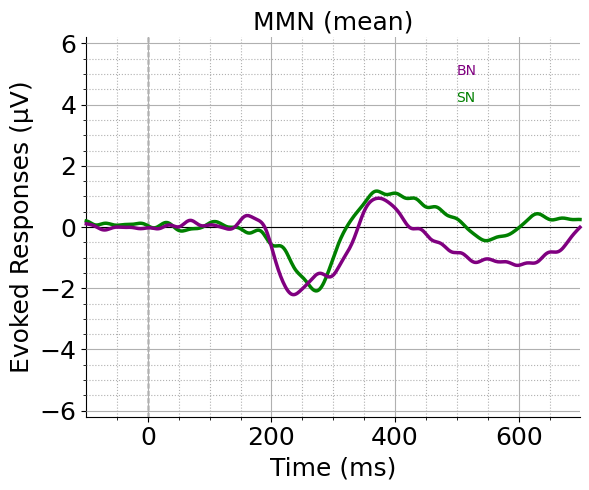

In [ ]:
MMN_evokeds = {
           'PN': [mne.combine_evoked([SN_deviant['evoke'], SN_sta['evoke'] ], weights=[1, -1])] ,
           'BN':[mne.combine_evoked([BN_deviant['evoke'], BN_sta['evoke'] ], weights=[1, -1]) ],
                      }
stylesdict ={
             "BN": {"linewidth": 2.5,"linestyle":'solid','color': 'purple'},
             'PN': {"linewidth": 2.5,"linestyle":'solid','color': 'green'},
             }
text_labels = [ 
    (0.90, "BN",'purple'),
    (0.83, f"SN",'green'),
] 
plot_erps(MMN_evokeds, picks=["Cz",'Fz','FCz'] ,
                                   stylesdict=stylesdict,
                                   text_labels=text_labels,title="MMN")
plt.tight_layout()
plt.show()

NameError: name 'ci95' is not defined

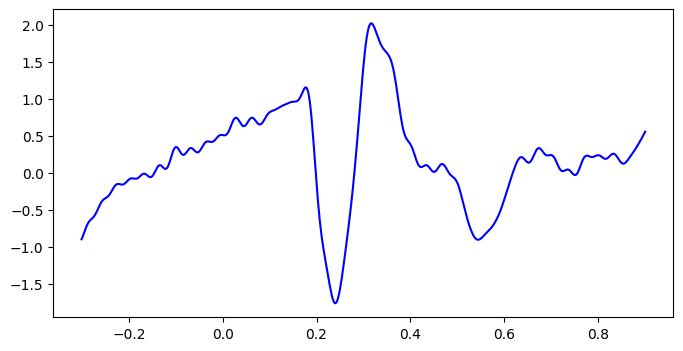

In [16]:
# Step 1: Compute mean ERP (Evoked) across all epochs
evoked = mne.combine_evoked([SN_deviant['evoke'], SN_sta['evoke'] ], weights=[1, -1])
# Step 2: Extract data from epochs (shape: n_epochs x n_channels x n_times)

# n_epochs = SN_deviant['trial_details']['total_trial']

# # Step 3: Compute mean and 95% confidence inter val (per channel, per time)
mean_data = SN_deviant['mean']
# std_data = SN_deviant['SD']
# stderr = std_data / cp.sqrt(n_epochs)
# ci95 = 1.96 * stderr  # 95% confidence interval


 
# Step 5: Plot ERP with CI for a single channel
channel = 'Fz'  # choose your channel
ch_idx = evoked.ch_names.index(channel)
times = evoked.times

plt.figure(figsize=(8, 4))
plt.plot(times, mean_data[ch_idx] * 1e6, label='ERP (Mean)', color='blue')
plt.fill_between(
    times,
    (mean_data[ch_idx] - ci95[ch_idx]) * 1e6,
    (mean_data[ch_idx] + ci95[ch_idx]) * 1e6,
    color='blue', alpha=0.3, label='95% CI'
)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title(f'ERP at {channel} with 95% Confidence Interval')
plt.legend()
plt.tight_layout()
plt.show()